# Pneumonia X-Ray CNN — run this in Google Colab

This notebook clones the repo, installs dependencies, downloads the dataset, trains a
model, and generates the plots/example-prediction image used in the README.



## 1. Checking if the GPU is on

In [1]:
!nvidia-smi

Thu Jul 30 19:39:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone the repo

In [2]:
import os
os.chdir('/content')
!rm -rf pneumonia-xray-cnn  # in case a previous run left a partial clone
!git clone https://github.com/rohithsure2000/pneumonia-xray-cnn.git
%cd pneumonia-xray-cnn
!pwd  # should print /content/pneumonia-xray-cnn -- check this before continuing

Cloning into 'pneumonia-xray-cnn'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 91 (delta 32), reused 79 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 823.23 KiB | 4.24 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/pneumonia-xray-cnn
/content/pneumonia-xray-cnn


## 3. Install dependencies
(Colab already has TensorFlow, but this makes sure versions match `requirements.txt`.)

In [3]:
%cd /content/pneumonia-xray-cnn
!pip install -q -r requirements.txt
!pip install -q -e .

/content/pneumonia-xray-cnn
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pneumonia-xray-cnn (pyproject.toml) ... done


## 4. Upload your Kaggle API token
In [kaggle.com/settings](https://www.kaggle.com/settings).

Need to download "kaggle.json" and upload here.

In [4]:
%cd /content/pneumonia-xray-cnn
from google.colab import files
uploaded = files.upload()  # select the kaggle.json you just downloaded

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

/content/pneumonia-xray-cnn


Saving kaggle.json to kaggle.json


## 5. Download the dataset
This pulls the ~2.2 GB Kaggle dataset and unzips it into `data/chest_xray`.

In [5]:
%cd /content/pneumonia-xray-cnn
!bash scripts/download_data.sh data

/content/pneumonia-xray-cnn
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 136MB/s]

Extracting...
Flattening the archive's extra nested chest_xray/ folder...
mv: cannot move 'chest_xray/chest_xray/test' to 'chest_xray/test': Directory not empty
mv: cannot move 'chest_xray/chest_xray/train' to 'chest_xray/train': Directory not empty
mv: cannot move 'chest_xray/chest_xray/val' to 'chest_xray/val': Directory not empty


## 6. Train a model
`improved` is the custom regularized CNN that performed best in the original comparison.
Can swap `--model` for `basic`, `vgg16`, `vgg19`, or `resnet50` to train a different architecture, run this cell again with a different value to build up the full comparison table.

In [6]:
%cd /content/pneumonia-xray-cnn
!python -m pneumonia_cnn.train \
    --model improved \
    --data-dir data/chest_xray \
    --output-dir artifacts \
    --epochs 15

/content/pneumonia-xray-cnn
2026-07-30 19:40:40.686879: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-30 19:40:43,066 INFO NumExpr defaulting to 2 threads.
2026-07-30 19:40:45,545 INFO Loading dataset from data/chest_xray
Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
2026-07-30 19:40:49,491 INFO Building model 'improved'
2026-07-30 19:40:50.930003: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1785440450.931492    1914 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 

## 7. Look at the results

In [7]:
%cd /content/pneumonia-xray-cnn
!cat artifacts/improved/test_metrics.json

/content/pneumonia-xray-cnn
{
  "true_negatives": 156,
  "false_positives": 78,
  "false_negatives": 35,
  "true_positives": 355,
  "accuracy": 0.8189102564102564,
  "precision": 0.8198614318706697,
  "recall": 0.9102564102564102,
  "f1_score": 0.8626974483596598
}

/content/pneumonia-xray-cnn


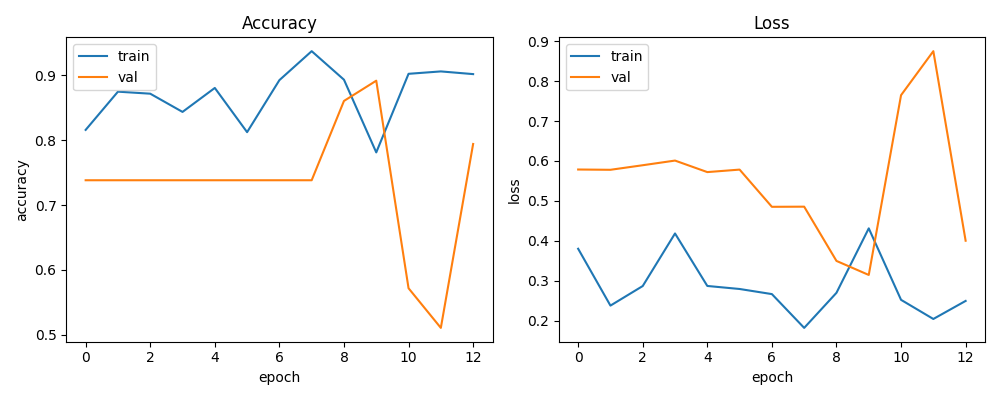

In [8]:
%cd /content/pneumonia-xray-cnn
from IPython.display import Image, display
display(Image('artifacts/improved/training_curves.png'))

## 8. Generate the example-predictions image for the README
This saves a grid of test images with their true/predicted labels, colored green (correct) or red (incorrect).

In [9]:
%cd /content/pneumonia-xray-cnn
!python scripts/visualize_predictions.py \
    --model-path artifacts/improved/model.keras \
    --data-dir data/chest_xray \
    --output docs/assets/example_predictions.png

/content/pneumonia-xray-cnn
2026-07-30 19:50:31.062742: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading model from artifacts/improved/model.keras
2026-07-30 19:50:35.523932: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1785441035.525503    4598 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Loading test images from data/chest_xray/test
2026-07-30 19:50:40.775581: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 168480000 ex

/content/pneumonia-xray-cnn


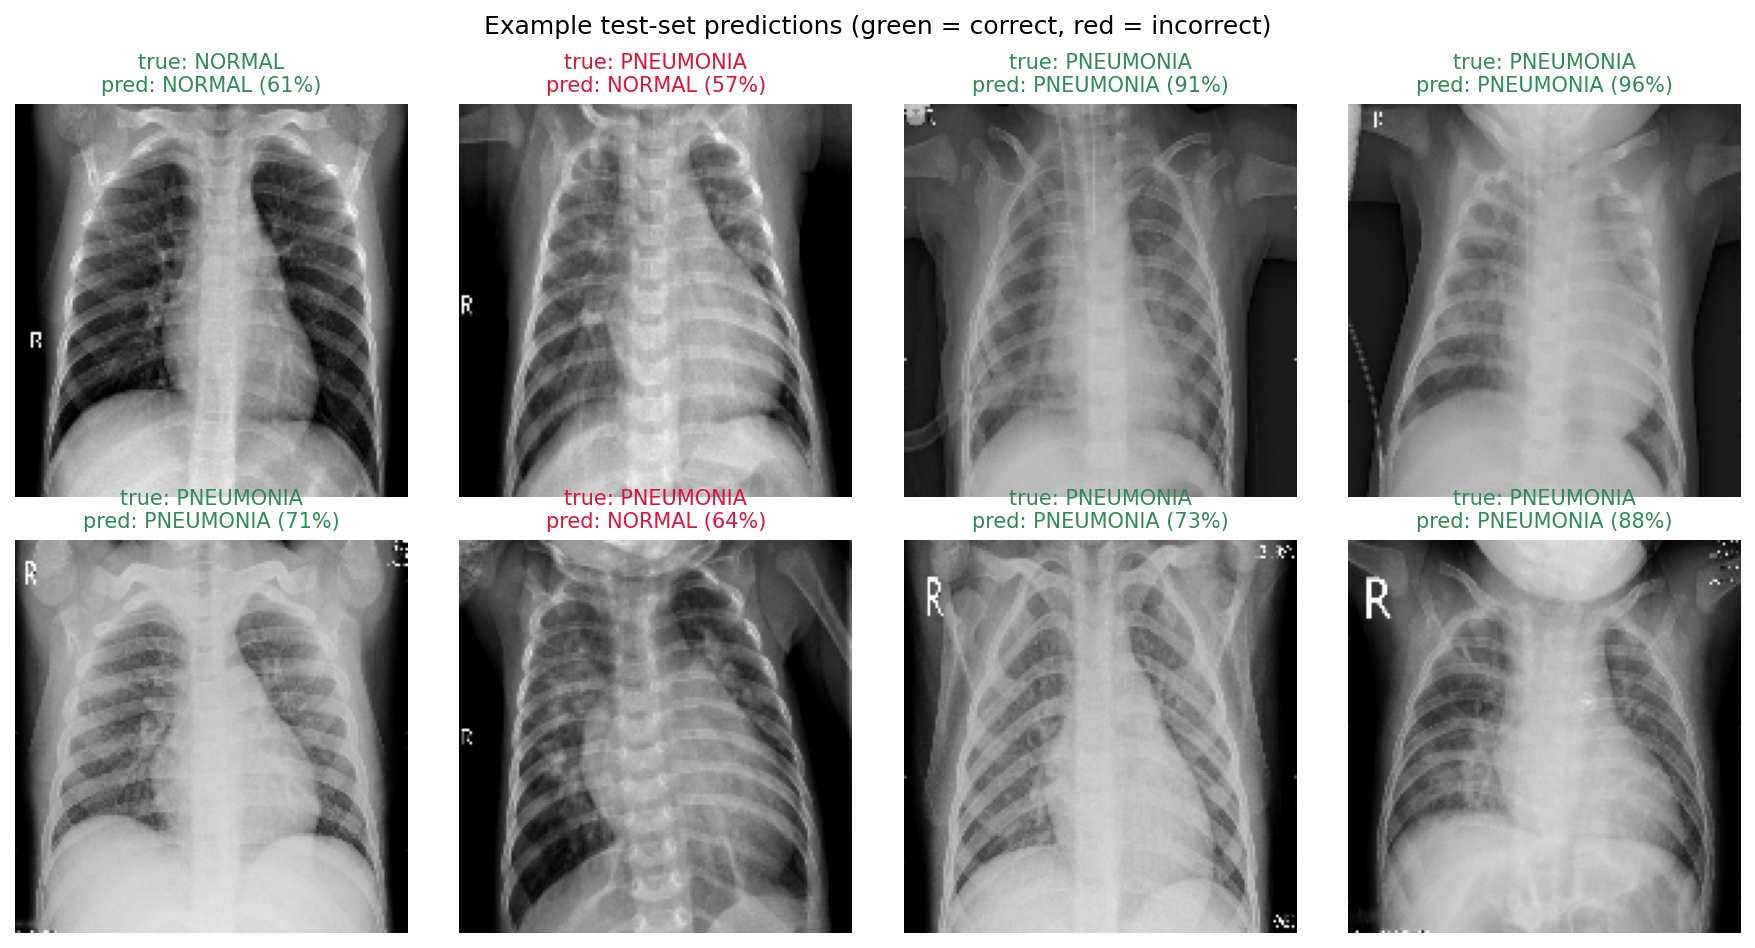

In [10]:
%cd /content/pneumonia-xray-cnn
from IPython.display import Image, display
display(Image('docs/assets/example_predictions.png'))

## 9. Downloads everything back to the computer


In [11]:
%cd /content/pneumonia-xray-cnn
!zip -r results.zip artifacts docs/assets
from google.colab import files
files.download('results.zip')

/content/pneumonia-xray-cnn
  adding: artifacts/ (stored 0%)
  adding: artifacts/improved/ (stored 0%)
  adding: artifacts/improved/training_curves.png (deflated 5%)
  adding: artifacts/improved/best_weights.weights.h5 (deflated 7%)
  adding: artifacts/improved/test_metrics.json (deflated 41%)
  adding: artifacts/improved/model.keras (deflated 7%)
  adding: docs/assets/ (stored 0%)
  adding: docs/assets/training_curves.png (deflated 7%)
  adding: docs/assets/example_predictions.png (deflated 1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>